In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob

Just plotting

In [3]:
def pick_and_fit_linear_region(df=None,labelStr='Data', x_col=None, v_col=None, ch="Channel 1", i1=0, i2=100):

    # (csv_path...)
    if isinstance(df, pd.DataFrame):
        cols = list(df.columns)
        # determine voltage column

        if v_col is None:
            v_candidates = [c for c in cols if ch in c]
            if v_candidates:
                v_col = v_candidates[0]
            else:
                # fallback to second column if available
                v_col = cols[1] if len(cols) >= 2 else cols[0]
        if x_col is None:
            x_um = df.index 
        else:
            x_um = df[x_col].to_numpy().astype(float)
        V = df[v_col].to_numpy().astype(float)
        labelStr = labelStr or os.path.basename(data)
    else:
        raise ValueError('When passing arrays, both x_um and V must be provided')

    if len(x_um) != len(V):
        raise ValueError('x and V must have same length.')
    N = len(V)

    print(len(x_um), N)
    idx = np.arange(1, N+1)
    
    # --- Plot vs index first (as the lab says) ---
    fig, axs = plt.subplots(1, 1)
    
    # --- Fit in chosen region ---
    xr = x_um[i1-1:i2]
    Vr = V[i1-1:i2]

    # print(xr, Vr)
    p = np.polyfit(xr, Vr, 1)  # V = p[0]*x + p[1]
    Vfit = np.polyval(p, xr)
    slope = p[0]
    linWidth = max(xr) - min(xr)
    
    # --- Plot vs position + show fit ---



    # axs[0].plot(x_um, V, 'k-')
    # axs[0].plot(xr, Vr, 'b.', markersize=10)
    # axs[0].plot(xr, Vfit, 'r-', linewidth=2)
    # axs[0].grid(True)
    # axs[0].set_xlabel('X')
    # axs[0].set_ylabel('Voltage (V)')
    # axs[0].set_title(f'{labelStr}: slope = {slope:.6g} | width = {linWidth:.6g} | indices [{i1},{i2}]')
    # axs[0].legend(['All data', 'Chosen region', 'Linear fit'], loc='best')
    axs.plot(x_um, V, 'k-')
    axs.plot(xr, Vr, 'b.', markersize=10)
    axs.plot(xr, Vfit, 'r-', linewidth=2)
    axs.grid(True)
    axs.set_xlabel('X')
    axs.set_ylabel('Voltage (V)')
    axs.set_title(f'{labelStr}: slope = {slope:.6g} | width = {linWidth:.6g} | indices [{i1},{i2}]')
    axs.legend(['All data', 'Chosen region', 'Linear fit'], loc='best')


    plt.show()
    
    out = {
        'i_start': i1,
        'i_end': i2,
        'slope': slope,
        'intercept': p[1],
        'linWidth': linWidth
    }
    return out

In [4]:
#files = glob.glob("250/d-u-d-u.csv","300/d-u-d-u.csv","350/d-u-d-u.csv","400/d-u-d-u.csv","450/d-u-d-u.csv") # change this

def display_files(files):
    for file in files:
        df = pd.read_csv(file,on_bad_lines='skip') # change this
        print(f"Now reading: {file}")
        #df = pd.read_csv("250/d-u-d-u.csv") # change this
    
        coltype = 'Channel 1'
        # coltype = 'Channel 2'
    
        col_candidates = [c for c in df.columns if coltype in c]
        if not col_candidates:
            print('CSV columns:', df.columns.tolist())
            raise SystemExit('Could not find a Channel 1 column in the CSV')
    
        col = col_candidates[0]
        y = df[col]
        x = df.index
    
        plt.figure(figsize=(10,4))
        plt.plot(x, y, '-', linewidth=0.8)
        plt.xlabel('Sample Index')
        plt.ylabel(col)
        plt.title('Sample Index vs ' + col)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()



Now reading: 300/right-left-right-left.csv


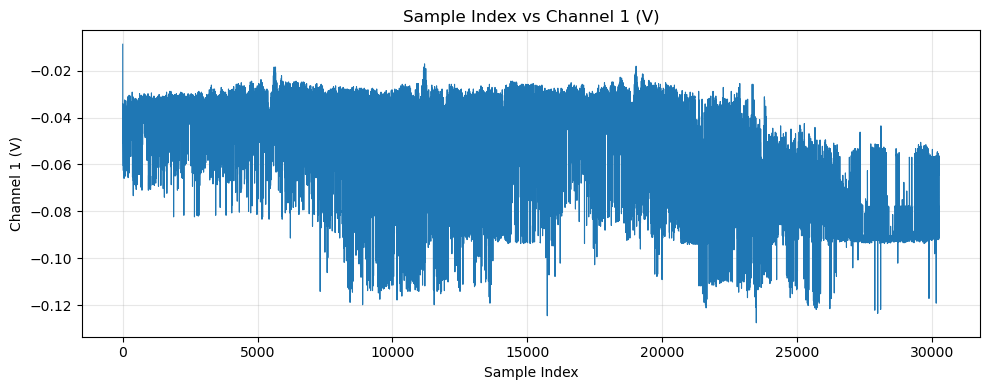

Now reading: 350/right-left-right-left.csv


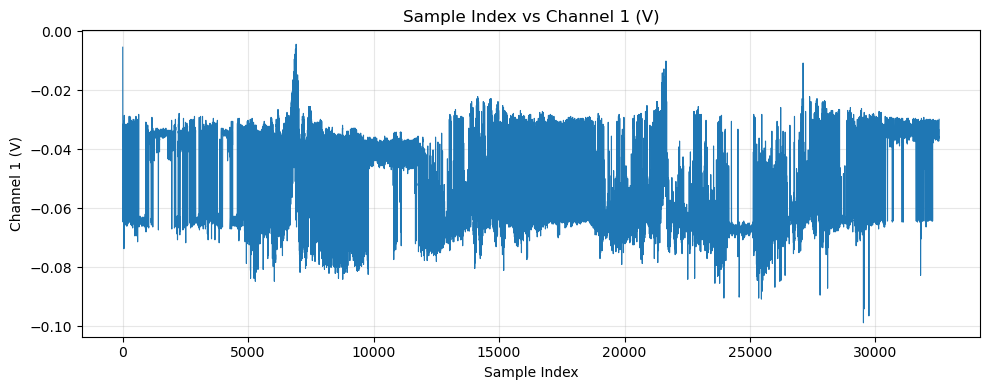

Now reading: 250/right-left-right-left.csv


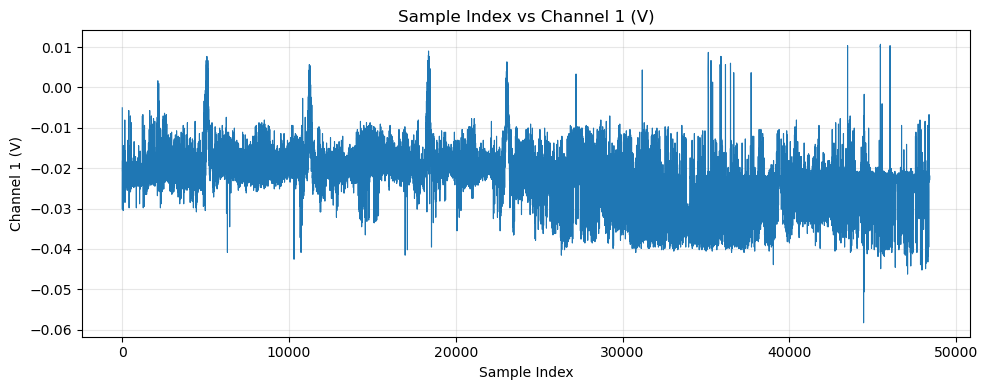

Now reading: 450/right-left-right-left.csv


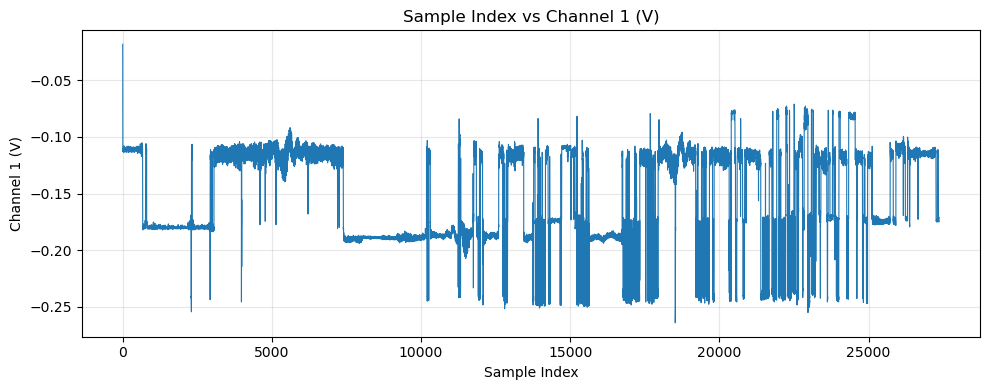

Now reading: 400/right-left-right-left.csv


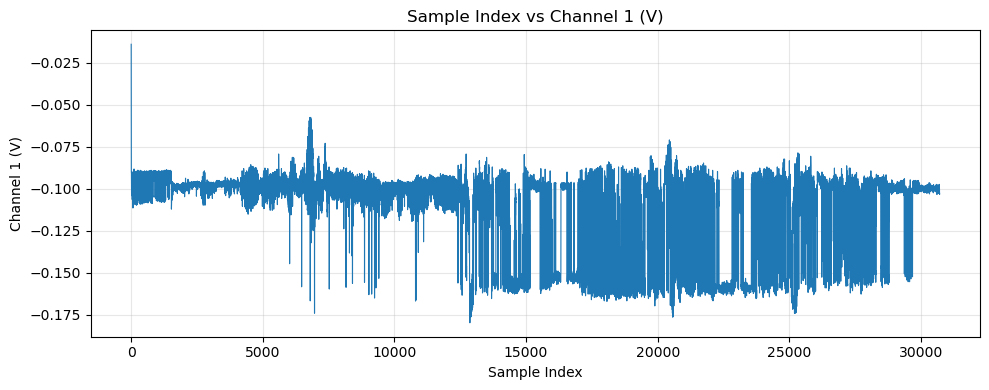

In [5]:
files = glob.glob('**/right-left-right-left.csv', recursive=True)
display_files(files)

Now reading: 300/d-u-d-u.csv


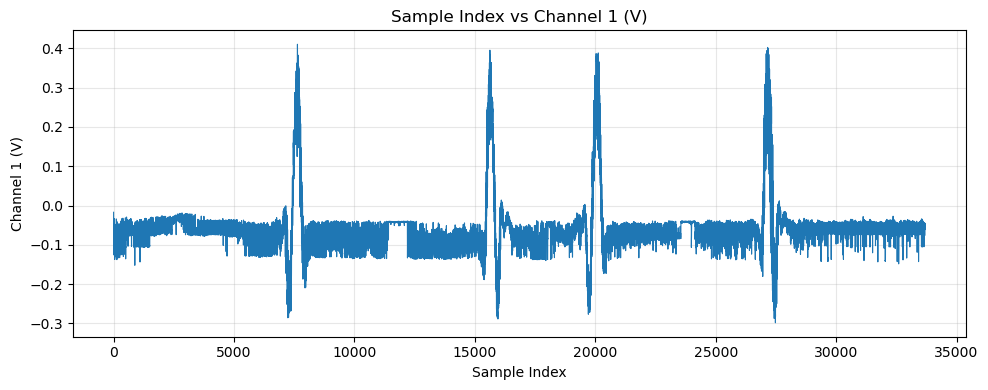

Now reading: 350/d-u-d-u.csv


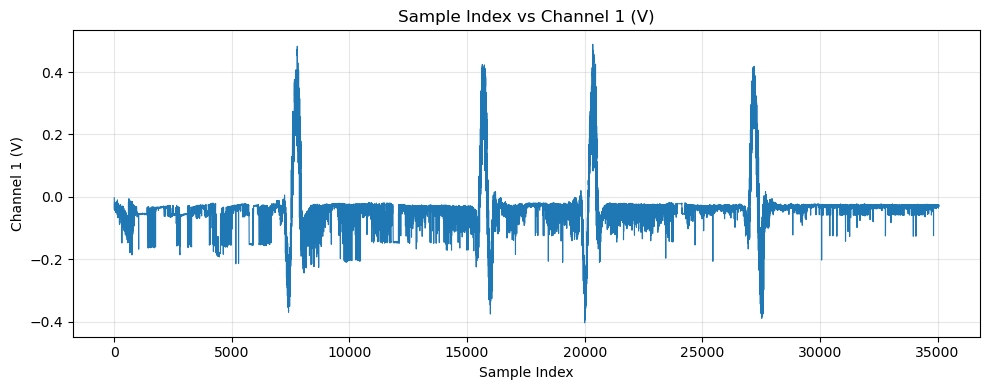

Now reading: 250/d-u-d-u.csv


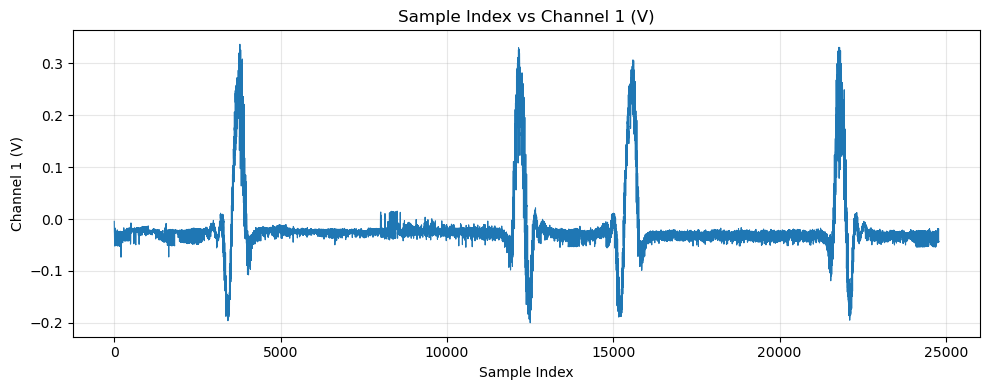

Now reading: 450/d-u-d-u.csv


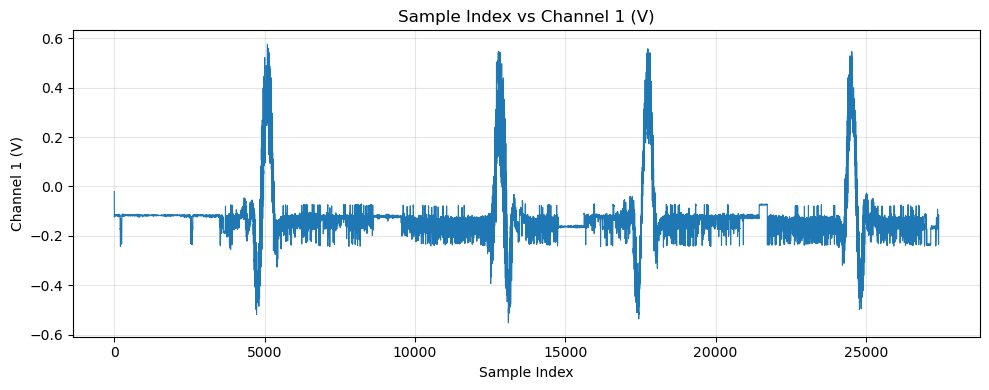

Now reading: 400/d-u-d-u.csv


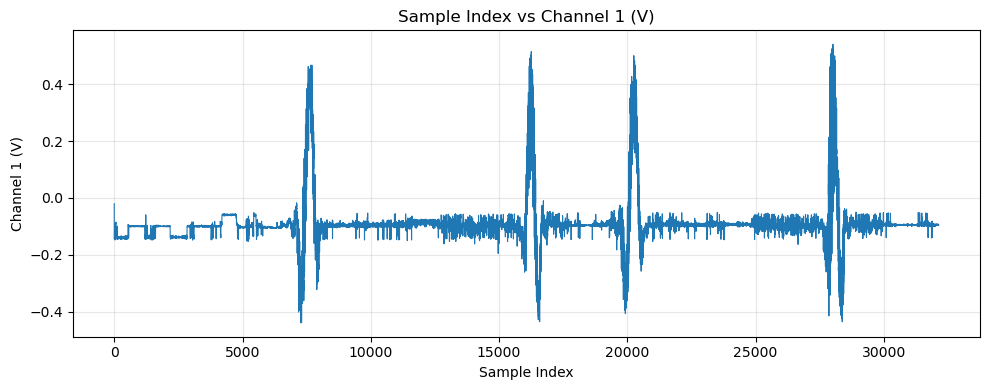

In [6]:
files = glob.glob('**/d-u-d-u.csv', recursive=True)
display_files(files)

### 250

DOWN

In [10]:
pd_250 = pd.read_csv("250/d-u-d-u.csv")

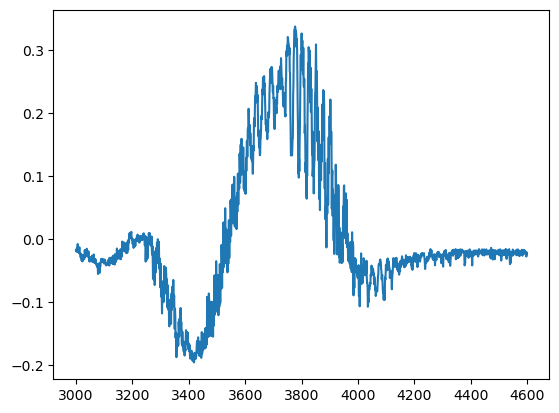

In [33]:
pd_250_d = pd_250[3000:4600]
plt.plot(pd_250_d.index, pd_250_d.iloc[:,1])

1600 1600


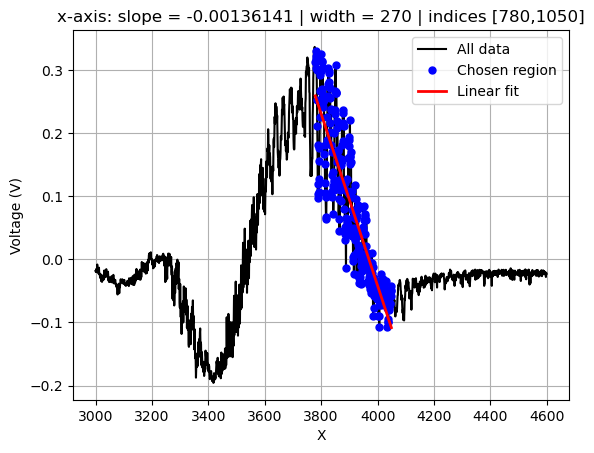

{'i_start': 780,
 'i_end': 1050,
 'slope': np.float64(-0.0013614132423359535),
 'intercept': np.float64(5.40421734895315),
 'linWidth': 270}

In [34]:
pick_and_fit_linear_region(pd_250_d, labelStr="x-axis", ch="Channel 1", i1=3780-3000, i2=4050-3000)

UP

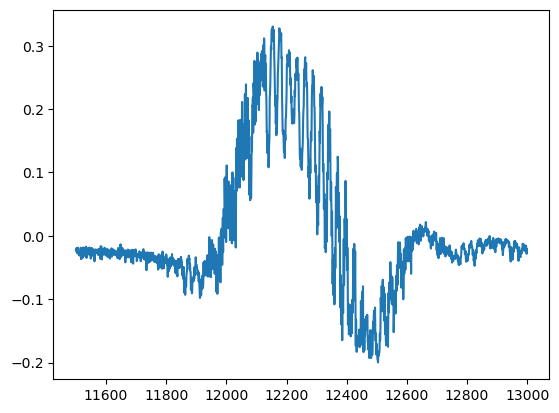

In [35]:
pd_250_u = pd_250[11500:13000]
plt.plot(pd_250_u.index, pd_250_u.iloc[:,1])

1500 1500


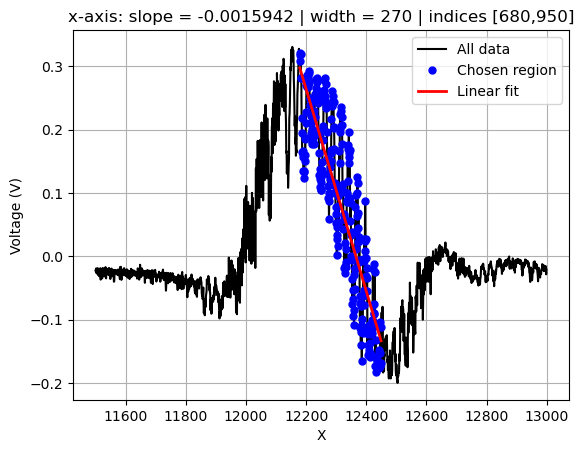

{'i_start': 680,
 'i_end': 950,
 'slope': np.float64(-0.001594199978036598),
 'intercept': np.float64(19.712871487711585),
 'linWidth': 270}

In [38]:
pick_and_fit_linear_region(pd_250_u, labelStr="x-axis", ch="Channel 1", i1=12180-11500, i2=12450-11500)

### 300

2000 2000


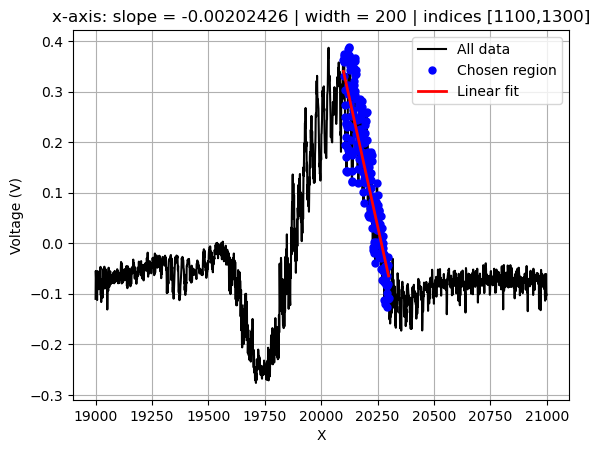

{'i_start': 1100, 'i_end': 1300, 'slope': np.float64(-0.002024260855633783), 'intercept': np.float64(41.025591271891926), 'linWidth': 200}
2000 2000


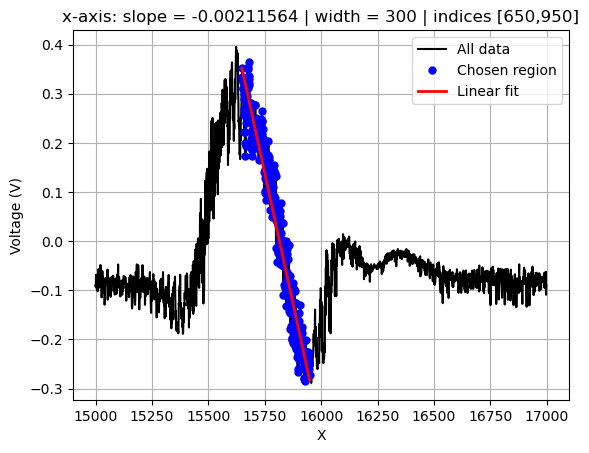

{'i_start': 650,
 'i_end': 950,
 'slope': np.float64(-0.002115637052962981),
 'intercept': np.float64(33.459727133982604),
 'linWidth': 300}

In [20]:
pd_300 = pd.read_csv("300/d-u-d-u.csv")
pd_300_d = pd_300[19000:21000]
pd_300_u = pd_300[15000:17000]
print(pick_and_fit_linear_region(pd_300_d, labelStr="x-axis", ch="Channel 1", i1=20100-19000, i2=20300-19000))
pick_and_fit_linear_region(pd_300_u, labelStr="x-axis", ch="Channel 1", i1=15650-15000, i2=15950-15000)

### 350

2000 2000


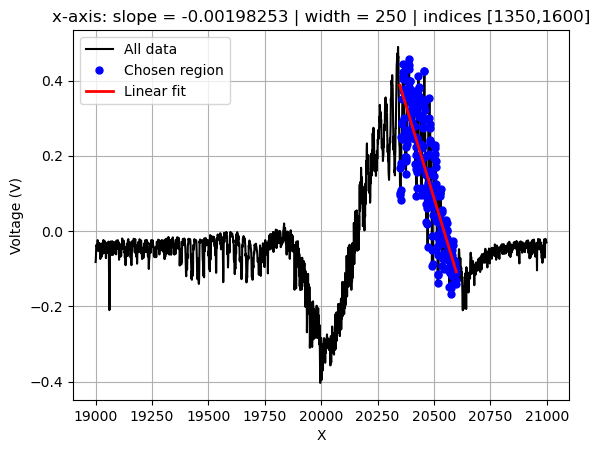

{'i_start': 1350, 'i_end': 1600, 'slope': np.float64(-0.001982531443548939), 'intercept': np.float64(40.72991161182522), 'linWidth': 250}
2000 2000


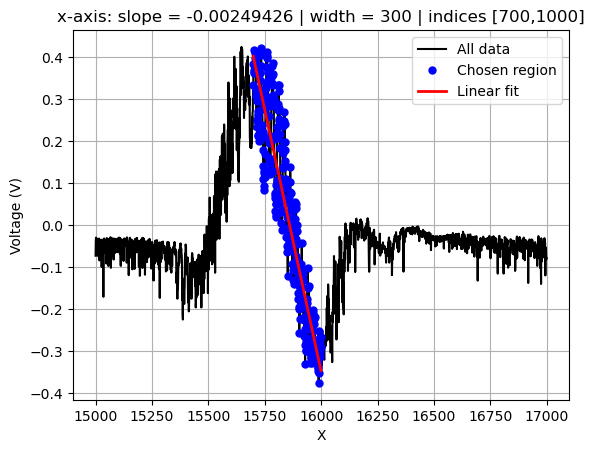

{'i_start': 700,
 'i_end': 1000,
 'slope': np.float64(-0.0024942590948170045),
 'intercept': np.float64(39.5596044847988),
 'linWidth': 300}

In [19]:
pd_350 = pd.read_csv("350/d-u-d-u.csv")
pd_350_d = pd_350[19000:21000]
# plt.plot(pd_350_d.index, pd_350_d.iloc[:,1])
print(pick_and_fit_linear_region(pd_350_d, labelStr="x-axis", ch="Channel 1", i1=20350-19000, i2=20600-19000))
pd_350_u = pd_350[15000:17000]
# plt.plot(pd_350_u.index, pd_350_u.iloc[:,1])
pick_and_fit_linear_region(pd_350_u, labelStr="x-axis", ch="Channel 1", i1=15700-15000, i2=16000-15000)

### 400

2000 2000


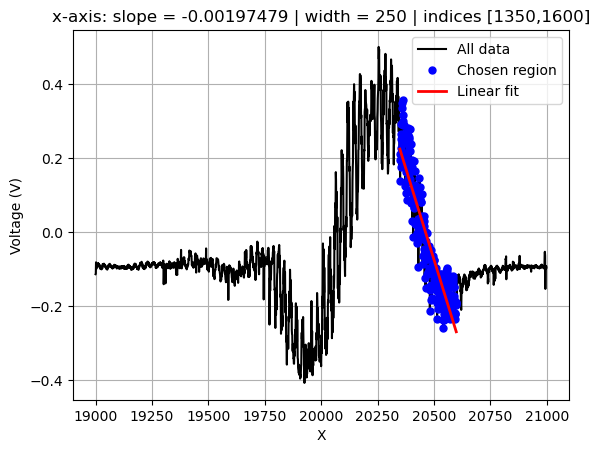

{'i_start': 1350, 'i_end': 1600, 'slope': np.float64(-0.0019747893053530807), 'intercept': np.float64(40.409892968807334), 'linWidth': 250}
2000 2000


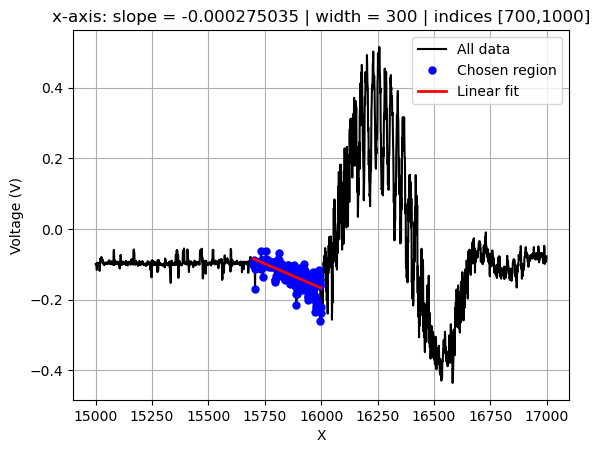

{'i_start': 700,
 'i_end': 1000,
 'slope': np.float64(-0.0002750346917920388),
 'intercept': np.float64(4.233476422389482),
 'linWidth': 300}

In [22]:
pd_400 = pd.read_csv("400/d-u-d-u.csv")
pd_400_d = pd_400[19000:21000]
# plt.plot(pd_350_d.index, pd_350_d.iloc[:,1])
print(pick_and_fit_linear_region(pd_400_d, labelStr="x-axis", ch="Channel 1", i1=20350-19000, i2=20600-19000))
pd_400_u = pd_400[15000:17000]
# plt.plot(pd_350_u.index, pd_350_u.iloc[:,1])
pick_and_fit_linear_region(pd_400_u, labelStr="x-axis", ch="Channel 1", i1=15700-15000, i2=16000-15000)

### 450

2000 2000


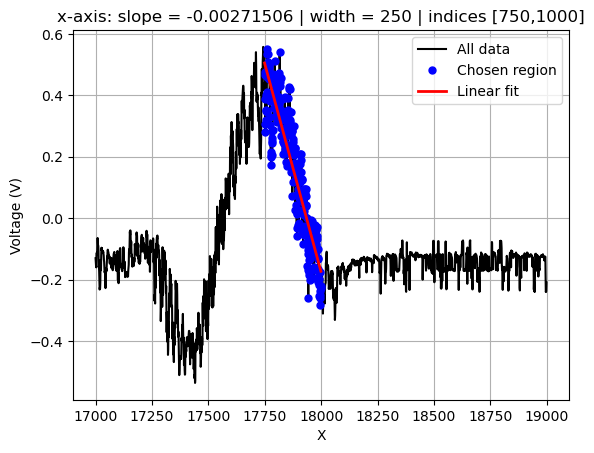

{'i_start': 750, 'i_end': 1000, 'slope': np.float64(-0.002715058975888877), 'intercept': np.float64(48.69516084397056), 'linWidth': 250}
2000 2000


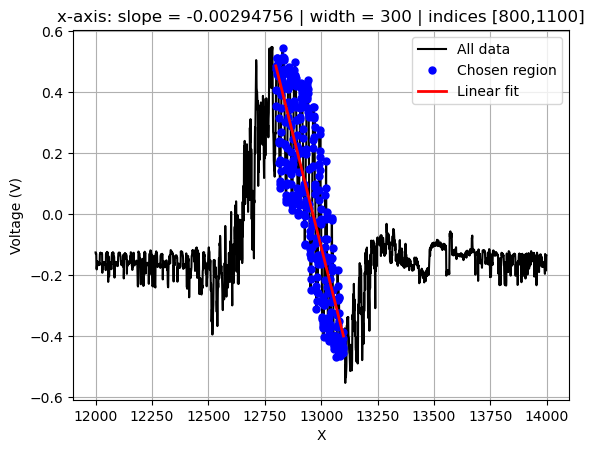

{'i_start': 800,
 'i_end': 1100,
 'slope': np.float64(-0.0029475642868915432),
 'intercept': np.float64(38.21141405107427),
 'linWidth': 300}

In [26]:
pd_450 = pd.read_csv("450/d-u-d-u.csv")
pd_450_d = pd_450[17000:19000]
# plt.plot(pd_350_d.index, pd_350_d.iloc[:,1])
print(pick_and_fit_linear_region(pd_450_d, labelStr="x-axis", ch="Channel 1", i1=17750-17000, i2=18000-17000))
pd_450_u = pd_450[12000:14000]
# plt.plot(pd_350_u.index, pd_350_u.iloc[:,1])
pick_and_fit_linear_region(pd_450_u, labelStr="x-axis", ch="Channel 1", i1=12800-12000, i2=13100-12000)

In [7]:
# conversion to correct (V/um) . slope should be roughly 0.1-0.2
# V/index * index / sampling frequency * (motor frequency) * (step / distance)

#  * 4000 / 4.83?

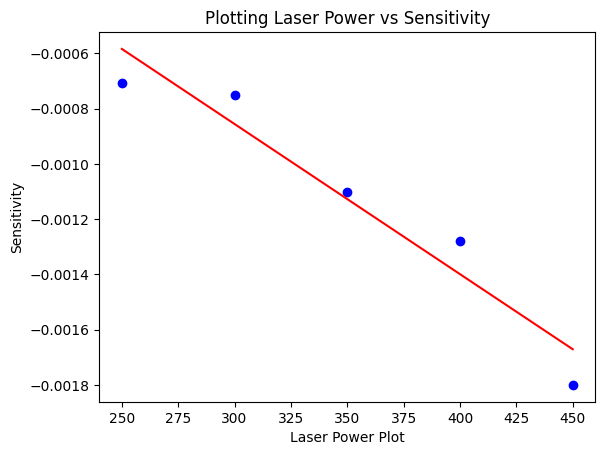

-5.435999999999997e-06


In [48]:
import matplotlib.pyplot as plt
import numpy as np

# Define 5 points (x, y coordinates)
y = np.array([-0.000706, -0.00075, -0.0011,-0.00128, -0.0018])
x = np.array([ 250, 300, 350, 400,450])
m, b = np.polyfit(x, y, 1)

# Plot the points as blue circles ('bo')
plt.scatter(x, y, color='blue', label='Data Points')
plt.plot(x, m*x + b, color='red', label='Line of Best Fit')

#plt.plot(x, y, 'bo')

# Customize labels and title

plt.xlabel('Laser Power Plot')
plt.ylabel('Sensitivity')
plt.title('Plotting Laser Power vs Sensitivity')

# Show the graph
plt.show()
print(m)

Now reading: PSD/50.csv


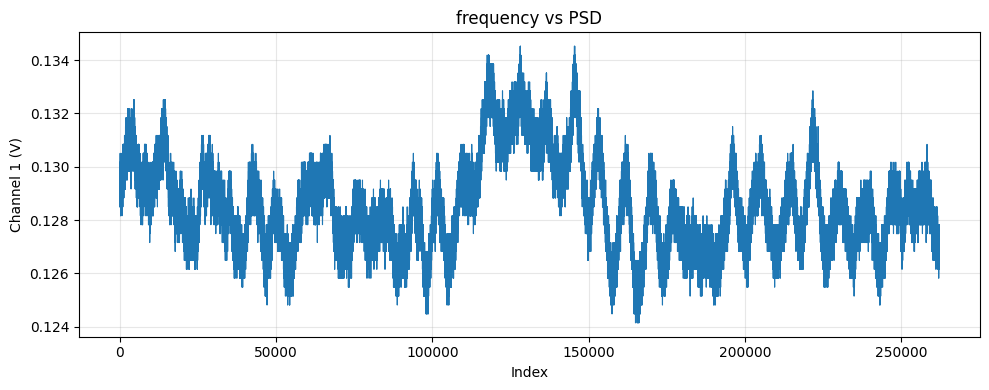

In [50]:
    df = pd.read_csv('PSD/50.csv',on_bad_lines='skip') # change this
    print(f"Now reading: {'PSD/50.csv'}")
    #df = pd.read_csv("250/d-u-d-u.csv") # change this

    coltype = 'Channel 1'
    # coltype = 'Channel 2'

    col_candidates = [c for c in df.columns if coltype in c]
    if not col_candidates:
        print('CSV columns:', df.columns.tolist())
        raise SystemExit('Could not find a Channel 1 column in the CSV')

    col = col_candidates[0]
    y = df[col]
    x = df.index

    plt.figure(figsize=(10,4))
    plt.plot(x, y, '-', linewidth=0.8)
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.title('frequency vs PSD')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


Now reading: PSD/50.csv


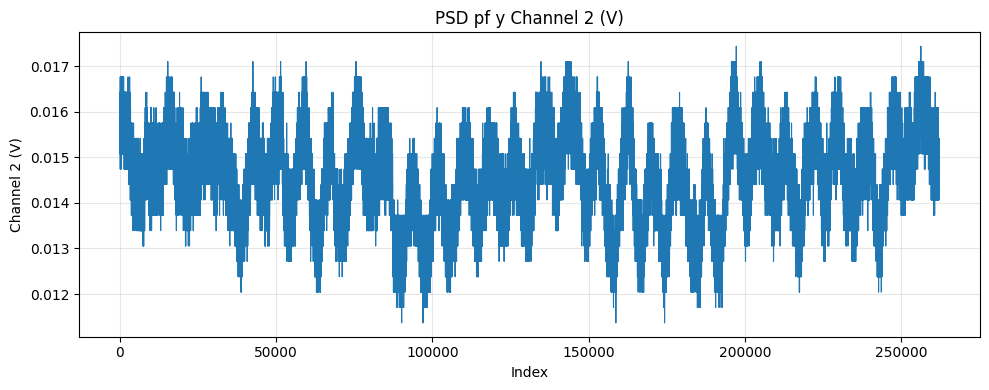

In [ ]:
    df = pd.read_csv('PSD/50.csv',on_bad_lines='skip') # change this
    print(f"Now reading: {'PSD/50.csv'}")
    #df = pd.read_csv("250/d-u-d-u.csv") # change this

    #coltype = 'Channel 1'
    coltype = 'Channel 2'

    col_candidates = [c for c in df.columns if coltype in c]
    if not col_candidates:
        print('CSV columns:', df.columns.tolist())
        raise SystemExit('Could not find a Channel 1 column in the CSV')

    col = col_candidates[0]
    y = df[col]
    x = df.index

    plt.figure(figsize=(10,4))
    plt.plot(x, y, '-', linewidth=0.8)
    plt.xlabel('Index')
    plt.ylabel(col)
    plt.title('PSD of y ' + col)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

(262144, 3)


C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\1703921683.py:24: RuntimeWarning: Mean of empty slice
  dt = np.diff(time).mean()
c:\Users\lexro\Downloads\111B\.venv\Lib\site-packages\numpy\_core\_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


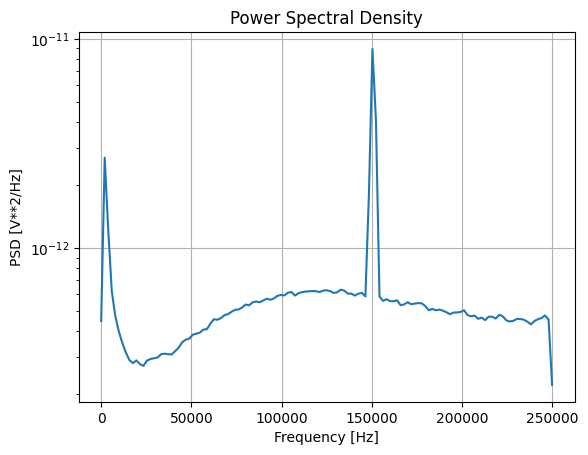

In [52]:
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# 1. Load your CSV file
df = pd.read_csv('PSD/50.csv', sep=',',skiprows = 0,on_bad_lines='skip')
print(df.shape)

# 2. Extract time and voltage
time = df.iloc[: 0].values
voltage = df.iloc[:, 1].values
# Ensure columns are numeric, coerce errors to NaN
#df[0] = (df[0])
#df[1] = pd.(df[1])
#df = df.dropna() # Remove any row with NaN

# 2. Extract time and voltage
# 'second row for iloc' fix: df.iloc[1:, 0] starts from row 2
#time = df.iloc[:, 0].values
#voltage = df.iloc[:, 1].values

# 3. Calculate sampling frequency (fs)
dt = np.diff(time).mean()
#fs = 1.0 / dt
fs= 500000

# 4. Compute PSD using Welch's method
frequencies, psd_x = signal.welch(voltage, fs=fs)

# 5. Plot the result (Optional)
plt.semilogy(frequencies, psd_x)
plt.title('Power Spectral Density')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid()
plt.show()

(262144, 3)


C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2151474234.py:24: RuntimeWarning: Mean of empty slice
  dt = np.diff(time).mean()


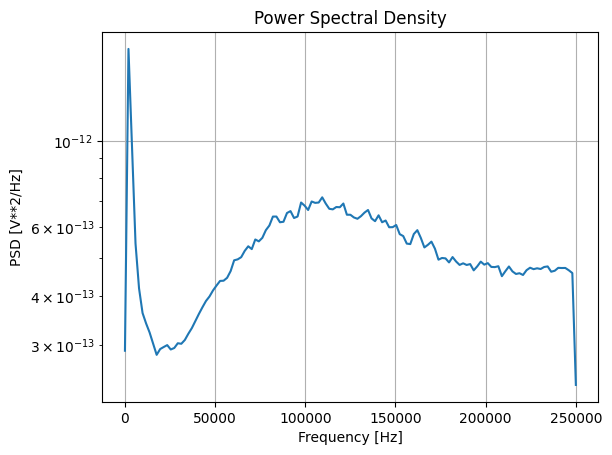

In [53]:
import pandas as pd
import numpy as np
from scipy import signal
import matplotlib.pyplot as plt

# 1. Load your CSV file
df = pd.read_csv('PSD/50.csv', sep=',',skiprows = 0,on_bad_lines='skip')
print(df.shape)

# 2. Extract time and voltage
time = df.iloc[: 0].values
voltage = df.iloc[:, 2].values
# Ensure columns are numeric, coerce errors to NaN
#df[0] = (df[0])
#df[1] = pd.(df[1])
#df = df.dropna() # Remove any row with NaN

# 2. Extract time and voltage
# 'second row for iloc' fix: df.iloc[1:, 0] starts from row 2
#time = df.iloc[:, 0].values
#voltage = df.iloc[:, 1].values

# 3. Calculate sampling frequency (fs)
dt = np.diff(time).mean()
#fs = 1.0 / dt
fs= 500000

# 4. Compute PSD using Welch's method
frequencies, psd_y = signal.welch(voltage, fs=fs)

# 5. Plot the result (Optional)
plt.semilogy(frequencies, psd_y)
plt.title('Power Spectral Density')
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [V**2/Hz]')
plt.grid()
plt.show()

In [59]:
import numpy as np
matrix = np.column_stack((frequencies, psd_x,psd_y))
print(matrix)

[[0.00000000e+00 4.47491512e-13 2.89604311e-13]
 [1.95312500e+03 2.70093735e-12 1.71715556e-12]
 [3.90625000e+03 1.22040842e-12 9.62554210e-13]
 [5.85937500e+03 6.23048498e-13 5.45023474e-13]
 [7.81250000e+03 4.73771794e-13 4.18347703e-13]
 [9.76562500e+03 3.99250413e-13 3.61706703e-13]
 [1.17187500e+04 3.51553290e-13 3.40211101e-13]
 [1.36718750e+04 3.16774295e-13 3.22453816e-13]
 [1.56250000e+04 2.91143477e-13 3.01717578e-13]
 [1.75781250e+04 2.81710035e-13 2.82662001e-13]
 [1.95312500e+04 2.90196959e-13 2.92468227e-13]
 [2.14843750e+04 2.78494769e-13 2.96017733e-13]
 [2.34375000e+04 2.73268966e-13 2.99352655e-13]
 [2.53906250e+04 2.89563551e-13 2.91725892e-13]
 [2.73437500e+04 2.94635928e-13 2.94305408e-13]
 [2.92968750e+04 2.97274584e-13 3.02645897e-13]
 [3.12500000e+04 2.99359958e-13 3.01755266e-13]
 [3.32031250e+04 3.10693356e-13 3.08552997e-13]
 [3.51562500e+04 3.12477096e-13 3.20137779e-13]
 [3.71093750e+04 3.10628782e-13 3.31050107e-13]
 [3.90625000e+04 3.09889687e-13 3.452846

In [42]:
#Fit Log Curve Variable X V2

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def fitlogcurvevarX(*args):
    # Input args in the form "data1,pwr1,data2,pwr2,..."
    # This next loop concatenates all the power levels into a vector.
    # NOTE: The loops throughout this function check EVERY OTHER input in
    # args, due to the convenience of the order of the input (data,pwr,...)
    pwr = [args[i] for i in range(1, len(args), 2)]

    col = 'rgbcmyk'  # The 'color' string: each letter specifies a unique color
                     # for the plot (i.e. col[4] = 'm' --> magenta)
    a_x = []
    fo_x = []
    leg = []

    for i in range(0, len(args), 2):
        data = np.array(args[i])
        xdata = np.log(data[:2113, 0] * 0.75)
        ydata = np.log(data[:2113, 1])

        def logfun1(params1):
            Alpha1, rolloff1 = params1
            FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
            ErrorVector1 = FittedCurve1 - ydata
            sse1 = np.sum(ErrorVector1 ** 2)
            return sse1

        start_point = np.random.rand(2)
        res = minimize(logfun1, start_point, options={'maxiter': 100000, 'maxfev': 100000})
        estimates1 = res.x
        Alpha1, rolloff1 = estimates1

        # Plotting
        color = col[(i // 2) % 7]
        plt.plot(np.log10(np.exp(xdata)), (i // 2) + np.log10(np.exp(ydata)), '.' + color, markersize=4)
        sse1 = logfun1(estimates1)
        FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
        plt.plot(np.log10(np.exp(xdata)), (i // 2) + np.log10(np.exp(FittedCurve1)), color)

        # Legend strings
        str1 = f'Power {pwr[i//2]:.2g}'
        str2 = f'fitted curve a ={Alpha1:.4g} fo ={rolloff1:.4g}'
        leg.append(str1)
        leg.append(str2)

        # Concatenate alpha and rolloff values
        a_x.append(Alpha1)
        fo_x.append(rolloff1)

    plt.legend(leg)
    plt.xlabel('Log Frequency (Hz)')
    plt.ylabel('PSD (V^2/Hz)')
    plt.title('Log Power Spectral Density (X)')
    plt.show()

    return a_x, fo_x

C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2806925895.py:22: RuntimeWarning: divide by zero encountered in log
  xdata = np.log(data[:2113, 0] * 0.75)
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2806925895.py:33: OptimizeWarning: Unknown solver options: maxfev
  res = minimize(logfun1, start_point, options={'maxiter': 100000, 'maxfev': 100000})
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2806925895.py:27: RuntimeWarning: invalid value encountered in log
  FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2806925895.py:27: RuntimeWarning: invalid value encountered in log
  FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2806925895.py:27: RuntimeWarning: invalid value encountered in log
  FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\2806925895.py:39:

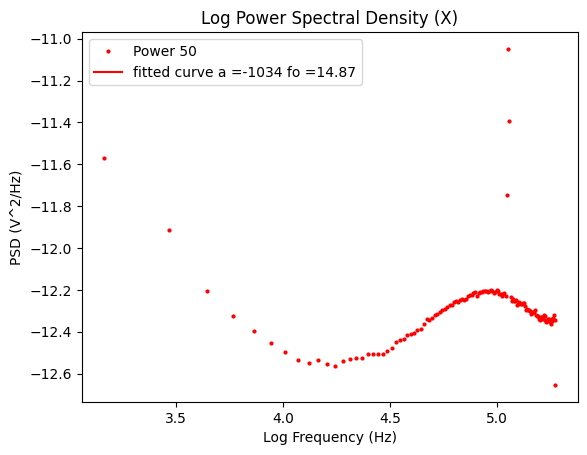

([np.float64(-1034.1088522213583)], [np.float64(14.869899742138498)])

In [60]:
fitlogcurvevarX(matrix,50)

In [62]:
#Fit Log Curve Variable Y V2

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def fitlogcurvevarY(*varargin):
    # Input varargin in the form "data1,pwr1,data2,pwr2,..."
    # This next loop concatenates all the power levels into a vector.
    # NOTE: The loops throughout this function check EVERY OTHER input in
    # varargin, due to the convenience of the order of the input (data,pwr,...)
    pwr = [varargin[i] for i in range(1, len(varargin), 2)]

    col = 'rgbcmyk'  # The 'color' string: each letter specifies a unique color
                     # for the plot (i.e. col[4] = 'm' --> magenta)
    a_y = []
    fo_y = []
    leg = []

    for i in range(0, len(varargin), 2):
        data = np.array(varargin[i])
        xdata = np.log(data[:2113, 0] * 0.75)
        ydata = np.log(data[:2113, 2])

        def logfun1(params1):
            Alpha1, rolloff1 = params1
            FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
            ErrorVector1 = FittedCurve1 - ydata
            sse1 = np.sum(ErrorVector1 ** 2)
            return sse1

        start_point = np.random.rand(2)
        res = minimize(logfun1, start_point, options={'maxiter': 100000, 'maxfev': 100000})
        estimates1 = res.x
        Alpha1, rolloff1 = estimates1

        # Plotting
        plt.plot(np.log10(np.exp(xdata)), ((i // 2) + np.log10(np.exp(ydata))),
                 '.', color=col[(i // 2) % 7], markersize=4)
        sse1 = logfun1(estimates1)
        FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
        plt.plot(np.log10(np.exp(xdata)), ((i // 2) + np.log10(np.exp(FittedCurve1))),
                 color=col[(i // 2) % 7])

        # Legend strings
        str_ = f'Power {pwr[i // 2]:.2g}'
        str2 = f'fitted curve a ={Alpha1:.4g} fo ={rolloff1:.4g}'
        leg.append(str_)
        leg.append(str2)

        # Concatenate alpha and rolloff values into vectors
        a_y.append(Alpha1)
        fo_y.append(rolloff1)

    plt.legend(leg)
    plt.xlabel('Log Frequency (Hz)')
    plt.ylabel('PSD (V^2/Hz)')
    plt.title('Log Power Spectral Density (Y)')
    plt.show()

    return a_y, fo_y

C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\3182031137.py:22: RuntimeWarning: divide by zero encountered in log
  xdata = np.log(data[:2113, 0] * 0.75)
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\3182031137.py:33: OptimizeWarning: Unknown solver options: maxfev
  res = minimize(logfun1, start_point, options={'maxiter': 100000, 'maxfev': 100000})
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\3182031137.py:27: RuntimeWarning: invalid value encountered in log
  FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\3182031137.py:27: RuntimeWarning: invalid value encountered in log
  FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\3182031137.py:27: RuntimeWarning: invalid value encountered in log
  FittedCurve1 = np.log(Alpha1) - np.log(rolloff1**2 + np.exp(xdata * 2))
C:\Users\lexro\AppData\Local\Temp\ipykernel_35420\3182031137.py:38:

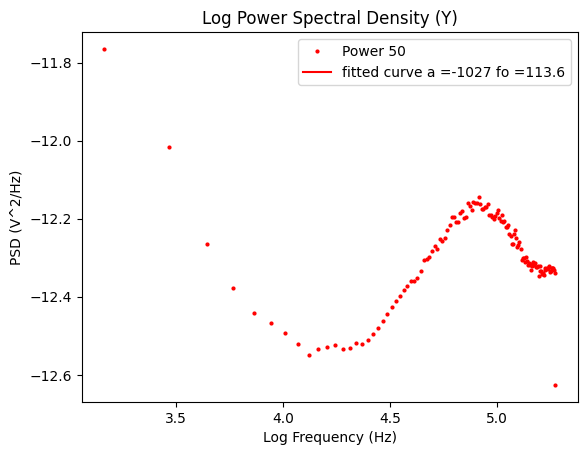

([np.float64(-1027.2842122828463)], [np.float64(113.56315695003015)])

In [63]:
fitlogcurvevarY(matrix,50)